# UA Tube Accuracy (www) Sensitivity Analysis

This notebook compares **hard UA tube** and **soft UA tube** over the full month of July for different `PhysicalParams.www` values.

Here `www` is the physical/forecast-error scaling parameter in `PhysicalParams`, not the soft-tube slack penalty. The soft slack penalty is kept fixed as `soft_slack_ww`. Both hard and soft UA tube can become infeasible or otherwise fail, so every run is wrapped and captured as either `status = "ok"` or `status = "error"`; the monthly sweep continues after failures.

In [1]:
from dataclasses import replace
from pathlib import Path
import sys
import time
import warnings

import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

project_root = Path.cwd()
if project_root.name == "UATMPC":
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from UATMPC import MPCConfig, Paths, PhysicalParams
from UATMPC.experiment import ExperimentRunner

paths = Paths.from_root(project_root)
base_config = MPCConfig()
base_params = PhysicalParams()

paths.results_dir.mkdir(parents=True, exist_ok=True)
figures_dir = paths.root / "UATMPC" / "figures"
figures_dir.mkdir(parents=True, exist_ok=True)

paths.results_dir

PosixPath('/Users/liqi/Desktop/UATMPC codes/UATMPC/results')

## Experiment Settings

`candidate_dates` defaults to July 1-31. If the first day has an incomplete history window in your data, change `range(1, 32)` to `range(2, 32)`.

`www_values` is the `PhysicalParams.www` grid. `soft_slack_ww` is only used by `runner.run_ua_tube_day(..., soft=True, ww=soft_slack_ww)` as the soft-constraint slack penalty.

In [2]:
candidate_month = 7
candidate_dates = [(candidate_month, day) for day in range(2, 32)]

# PhysicalParams.www values: forecast-error scaling in the closed-loop simulation.
www_values = [0.5, 0.8, 1.0, 1.2, 1.5]

# Soft-tube slack penalty. This is separate from PhysicalParams.www.
soft_slack_ww = 0.1

resume_from_csv = False
output_csv = paths.results_dir / f"accuracy_sensitivity_www_{candidate_month:02d}_results.csv"
solvability_csv = paths.results_dir / f"accuracy_sensitivity_www_{candidate_month:02d}_solvability.csv"
failures_csv = paths.results_dir / f"accuracy_sensitivity_www_{candidate_month:02d}_failures.csv"
economics_csv = paths.results_dir / f"accuracy_sensitivity_www_{candidate_month:02d}_economics.csv"
method_performance_csv = paths.results_dir / f"accuracy_sensitivity_www_{candidate_month:02d}_method_performance.csv"
comparison_csv = paths.results_dir / f"accuracy_sensitivity_www_{candidate_month:02d}_comparison.csv"

{
    "days": len(candidate_dates),
    "date_start": candidate_dates[0],
    "date_end": candidate_dates[-1],
    "n_www": len(www_values),
    "soft_slack_ww": soft_slack_ww,
    "output_csv": output_csv,
    "failures_csv": failures_csv,
    "method_performance_csv": method_performance_csv,
}

{'days': 30,
 'date_start': (7, 2),
 'date_end': (7, 31),
 'n_www': 5,
 'soft_slack_ww': 0.1,
 'output_csv': PosixPath('/Users/liqi/Desktop/UATMPC codes/UATMPC/results/accuracy_sensitivity_www_07_results.csv'),
 'failures_csv': PosixPath('/Users/liqi/Desktop/UATMPC codes/UATMPC/results/accuracy_sensitivity_www_07_failures.csv'),
 'method_performance_csv': PosixPath('/Users/liqi/Desktop/UATMPC codes/UATMPC/results/accuracy_sensitivity_www_07_method_performance.csv')}

## Helpers

Both hard and soft solvers can fail when their optimization problem is infeasible or when CVXPY returns no usable variable values. `run_safely` converts either failure into a row with `status = "error"`, so the notebook can keep running the remaining dates and `www` values.

In [3]:
runner_cache = {}


def format_www(www: float) -> str:
    return f"{float(www):g}"


def get_runner(www: float) -> ExperimentRunner:
    www_key = format_www(www)
    if www_key not in runner_cache:
        params = replace(base_params, www=float(www))
        runner_cache[www_key] = ExperimentRunner(paths, base_config, params).setup()
    return runner_cache[www_key]


def empty_metric_record(date, method, www, started_at, exc):
    return {
        "date_month": date[0],
        "date_day": date[1],
        "date": f"{date[0]:02d}-{date[1]:02d}",
        "method": method,
        "www_label": format_www(www),
        "www_value": float(www),
        "soft_slack_ww": soft_slack_ww if method == "soft_ua_tube" else np.nan,
        "runtime": time.time() - started_at,
        "total_cost": np.nan,
        "operational_cost": np.nan,
        "total_penalty": np.nan,
        "status": "error",
        "error_type": type(exc).__name__,
        "error": str(exc),
    }


def result_record(date, method, www, result):
    return {
        "date_month": date[0],
        "date_day": date[1],
        "date": f"{date[0]:02d}-{date[1]:02d}",
        "method": method,
        "www_label": format_www(www),
        "www_value": float(www),
        "soft_slack_ww": soft_slack_ww if method == "soft_ua_tube" else np.nan,
        "runtime": result["runtime"],
        "total_cost": result["total_cost"],
        "operational_cost": result["operational_cost"],
        "total_penalty": result["total_penalty"],
        "status": "ok",
        "error_type": "",
        "error": "",
    }


def run_safely(date, method, www):
    started_at = time.time()
    try:
        runner = get_runner(www)
        if method == "hard_ua_tube":
            result = runner.run_ua_tube_day(date, soft=False)
        elif method == "soft_ua_tube":
            result = runner.run_ua_tube_day(date, soft=True, ww=soft_slack_ww)
        else:
            raise ValueError(f"Unknown method: {method}")
        return result_record(date, method, www, result)
    except Exception as exc:
        return empty_metric_record(date, method, www, started_at, exc)


def record_key(record):
    return (
        int(record["date_month"]),
        int(record["date_day"]),
        str(record["method"]),
        format_www(record["www_value"]),
    )


def make_key(date, method, www):
    return (date[0], date[1], method, format_www(www))


def save_checkpoint(records):
    results = pd.DataFrame(records)
    results.to_csv(output_csv, index=False)
    return results

## Run Monthly Sweep

This cell writes `accuracy_sensitivity_www_07_results.csv` after every completed record. If the run is interrupted, leave `resume_from_csv = True` and rerun the cell.

In [4]:
if resume_from_csv and output_csv.exists():
    records = pd.read_csv(output_csv).to_dict("records")
    print(f"Loaded {len(records)} existing records from {output_csv}")
else:
    records = []

finished_keys = {record_key(record) for record in records}
candidate_methods = ["hard_ua_tube", "soft_ua_tube"]

for date in candidate_dates:
    print(f"Current date is: {date}")
    for www in www_values:
        print(f"  PhysicalParams.www = {www:g}")
        for method in candidate_methods:
            if make_key(date, method, www) in finished_keys:
                print(f"    Skip finished method: {method}")
                continue

            print(f"    Running {method}")
            record = run_safely(date, method, www)
            records.append(record)
            finished_keys.add(record_key(record))
            save_checkpoint(records)

            if record["status"] == "ok":
                print(
                    f"      ok: total_cost={record['total_cost']:.2f}, "
                    f"penalty={record['total_penalty']:.2f}, runtime={record['runtime']:.1f}s"
                )
            else:
                print(f"      failed: {record['error_type']}: {record['error']}")

results_df = save_checkpoint(records)
results_df

Current date is: (7, 2)
  PhysicalParams.www = 0.5
    Running hard_ua_tube
Set parameter Username
Set parameter LicenseID to value 2711611
Academic license - for non-commercial use only - expires 2026-09-22
      ok: total_cost=386.05, penalty=0.00, runtime=136.7s
    Running soft_ua_tube
      ok: total_cost=383.26, penalty=0.00, runtime=136.3s
  PhysicalParams.www = 0.8
    Running hard_ua_tube
      ok: total_cost=406.88, penalty=0.00, runtime=136.1s
    Running soft_ua_tube
      ok: total_cost=404.89, penalty=0.00, runtime=136.4s
  PhysicalParams.www = 1
    Running hard_ua_tube
      failed: TypeError: 'NoneType' object is not subscriptable
    Running soft_ua_tube
      ok: total_cost=420.03, penalty=0.00, runtime=136.4s
  PhysicalParams.www = 1.2
    Running hard_ua_tube
      failed: TypeError: 'NoneType' object is not subscriptable
    Running soft_ua_tube
      ok: total_cost=443.52, penalty=0.00, runtime=137.0s
  PhysicalParams.www = 1.5
    Running hard_ua_tube
      fail

,date_month,date_day,date,method,www_label,www_value,soft_slack_ww,runtime,total_cost,operational_cost,total_penalty,status,error_type,error
0,7,2,07-02,hard_ua_tube,0.5,0.5,NaN,136.735151,386.046926,386.046926,0.0,ok,,
1,7,2,07-02,soft_ua_tube,0.5,0.5,0.1,136.337019,383.256788,383.256788,0.0,ok,,
2,7,2,07-02,hard_ua_tube,0.8,0.8,NaN,136.136397,406.883911,406.883911,0.0,ok,,
3,7,2,07-02,soft_ua_tube,0.8,0.8,0.1,136.373162,404.894504,404.894504,0.0,ok,,
4,7,2,07-02,hard_ua_tube,1,1.0,NaN,38.386203,NaN,NaN,NaN,error,TypeError,'NoneType' object is not subscriptable
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,7,31,07-31,soft_ua_tube,1,1.0,0.1,136.499064,1158.324053,1158.324053,0.0,ok,,
296,7,31,07-31,hard_ua_tube,1.2,1.2,NaN,37.833286,NaN,NaN,NaN,error,TypeError,'NoneType' object is not subscriptable
297,7,31,07-31,soft_ua_tube,1.2,1.2,0.1,136.585567,1186.697888,1186.697888,0.0,ok,,
298,7,31,07-31,hard_ua_tube,1.5,1.5,NaN,36.314097,NaN,NaN,NaN,error,TypeError,'NoneType' object is not subscriptable


## Solvability Summary

`feasibility_rate` is computed from successful day-level runs for each `PhysicalParams.www` value.

In [5]:
results_df = pd.read_csv(output_csv)
results_df["is_feasible"] = results_df["status"].eq("ok")

solvability_df = (
    results_df
    .groupby(["www_value", "www_label", "method"], as_index=False)
    .agg(
        days_attempted=("status", "size"),
        feasible_days=("is_feasible", "sum"),
        failed_days=("is_feasible", lambda s: int((~s).sum())),
        runtime_sum=("runtime", "sum"),
        runtime_mean=("runtime", "mean"),
    )
    .sort_values(["www_value", "method"], ascending=[True, True])
)
solvability_df["feasibility_rate"] = solvability_df["feasible_days"] / solvability_df["days_attempted"]
solvability_df.to_csv(solvability_csv, index=False)
solvability_df

,www_value,www_label,method,days_attempted,feasible_days,failed_days,runtime_sum,runtime_mean,feasibility_rate
0,0.5,0.5,hard_ua_tube,30,30,0,4318.511746,143.950392,1.000000
1,0.5,0.5,soft_ua_tube,30,30,0,4335.063163,144.502105,1.000000
2,0.8,0.8,hard_ua_tube,30,24,6,3848.034859,128.267829,0.800000
3,0.8,0.8,soft_ua_tube,30,30,0,4333.899135,144.463304,1.000000
4,1.0,1.0,hard_ua_tube,30,7,23,1995.932610,66.531087,0.233333
5,1.0,1.0,soft_ua_tube,30,30,0,4344.190677,144.806356,1.000000
6,1.2,1.2,hard_ua_tube,30,2,28,1456.661456,48.555382,0.066667
7,1.2,1.2,soft_ua_tube,30,30,0,4320.856146,144.028538,1.000000
8,1.5,1.5,hard_ua_tube,30,0,30,1173.452850,39.115095,0.000000
9,1.5,1.5,soft_ua_tube,30,30,0,4336.204001,144.540133,1.000000


## Failure Details

This table keeps every failed hard or soft run. It is useful for checking which dates and `PhysicalParams.www` values caused infeasibility or missing solver values.

In [6]:
failures_df = (
    results_df[~results_df["status"].eq("ok")]
    .sort_values(["www_value", "date_month", "date_day", "method"])
    .loc[:, [
        "date_month", "date_day", "date", "method", "www_value", "www_label",
        "soft_slack_ww", "runtime", "error_type", "error",
    ]]
    .reset_index(drop=True)
)
failures_df.to_csv(failures_csv, index=False)
failures_df

,date_month,date_day,date,method,www_value,www_label,soft_slack_ww,runtime,error_type,error
0,7,15,07-15,hard_ua_tube,0.8,0.8,NaN,57.264383,TypeError,'NoneType' object is not subscriptable
1,7,16,07-16,hard_ua_tube,0.8,0.8,NaN,81.142292,TypeError,'NoneType' object is not subscriptable
2,7,26,07-26,hard_ua_tube,0.8,0.8,NaN,76.597177,TypeError,'NoneType' object is not subscriptable
3,7,27,07-27,hard_ua_tube,0.8,0.8,NaN,43.694043,TypeError,'NoneType' object is not subscriptable
4,7,28,07-28,hard_ua_tube,0.8,0.8,NaN,69.605708,TypeError,'NoneType' object is not subscriptable
...,...,...,...,...,...,...,...,...,...,...
82,7,27,07-27,hard_ua_tube,1.5,1.5,NaN,36.421901,TypeError,'NoneType' object is not subscriptable
83,7,28,07-28,hard_ua_tube,1.5,1.5,NaN,36.478193,TypeError,'NoneType' object is not subscriptable
84,7,29,07-29,hard_ua_tube,1.5,1.5,NaN,36.477881,TypeError,'NoneType' object is not subscriptable
85,7,30,07-30,hard_ua_tube,1.5,1.5,NaN,37.906071,TypeError,'NoneType' object is not subscriptable


## Economics Summary

Economics are aggregated over successful runs only. Check `days_success` before comparing monthly sums: if either hard or soft UA tube is infeasible on some days, its monthly sum is over fewer successful days.

In [7]:
successful_df = results_df[results_df["status"].eq("ok")].copy()

if successful_df.empty:
    economics_df = pd.DataFrame(
        columns=[
            "www_value", "www_label", "method", "soft_slack_ww", "days_success", "complete_month",
            "total_cost_mean", "total_cost_sum", "operational_cost_mean",
            "operational_cost_sum", "total_penalty_mean", "total_penalty_sum",
            "runtime_mean", "runtime_sum",
        ]
    )
else:
    economics_df = (
        successful_df
        .groupby(["www_value", "www_label", "method"], as_index=False)
        .agg(
            soft_slack_ww=("soft_slack_ww", "first"),
            days_success=("status", "size"),
            total_cost_mean=("total_cost", "mean"),
            total_cost_sum=("total_cost", "sum"),
            operational_cost_mean=("operational_cost", "mean"),
            operational_cost_sum=("operational_cost", "sum"),
            total_penalty_mean=("total_penalty", "mean"),
            total_penalty_sum=("total_penalty", "sum"),
            runtime_mean=("runtime", "mean"),
            runtime_sum=("runtime", "sum"),
        )
        .sort_values(["www_value", "method"], ascending=[True, True])
    )
    economics_df["complete_month"] = economics_df["days_success"].eq(len(candidate_dates))

economics_df.to_csv(economics_csv, index=False)
economics_df

,www_value,www_label,method,soft_slack_ww,days_success,total_cost_mean,total_cost_sum,operational_cost_mean,operational_cost_sum,total_penalty_mean,total_penalty_sum,runtime_mean,runtime_sum,complete_month
0,0.5,0.5,hard_ua_tube,NaN,30,902.631016,27078.930491,902.631016,27078.930490,2.200162e-08,6.600487e-07,143.950392,4318.511746,True
1,0.5,0.5,soft_ua_tube,0.1,30,895.600213,26868.006388,895.600213,26868.006386,6.394488e-08,1.918346e-06,144.502105,4335.063163,True
2,0.8,0.8,hard_ua_tube,NaN,24,963.075503,23113.812076,963.075503,23113.812076,0.000000e+00,0.000000e+00,143.286272,3438.870521,False
3,0.8,0.8,soft_ua_tube,0.1,30,935.273963,28058.218879,935.266847,28058.005404,7.115848e-03,2.134754e-01,144.463304,4333.899135,True
4,1.0,1.0,hard_ua_tube,NaN,7,1015.018825,7105.131776,1015.018825,7105.131776,0.000000e+00,0.000000e+00,145.698348,1019.888434,False
5,1.0,1.0,soft_ua_tube,0.1,30,972.630779,29178.923381,972.588434,29177.653028,4.234510e-02,1.270353e+00,144.806356,4344.190677,True
6,1.2,1.2,hard_ua_tube,NaN,2,1133.288017,2266.576035,1133.288017,2266.576035,0.000000e+00,0.000000e+00,165.376853,330.753706,False
7,1.2,1.2,soft_ua_tube,0.1,30,1008.779264,30263.377923,1008.622540,30258.676196,1.567242e-01,4.701727e+00,144.028538,4320.856146,True
8,1.5,1.5,soft_ua_tube,0.1,30,1052.212170,31566.365103,1051.775704,31553.271129,4.364658e-01,1.309397e+01,144.540133,4336.204001,True


## Hard vs Soft Comparison

This table aligns hard and soft UA tube by `PhysicalParams.www`. Cost differences are `soft - hard`, so negative values mean the soft method is cheaper among successful runs.

In [8]:
metric_cols = [
    "days_success", "complete_month", "total_cost_mean", "total_cost_sum",
    "operational_cost_mean", "operational_cost_sum", "total_penalty_mean",
    "total_penalty_sum", "runtime_mean", "runtime_sum",
]
solvability_cols = ["days_attempted", "feasible_days", "failed_days", "feasibility_rate"]

hard_econ = economics_df[economics_df["method"].eq("hard_ua_tube")].copy()
soft_econ = economics_df[economics_df["method"].eq("soft_ua_tube")].copy()
hard_sol = solvability_df[solvability_df["method"].eq("hard_ua_tube")].copy()
soft_sol = solvability_df[solvability_df["method"].eq("soft_ua_tube")].copy()

hard_econ = hard_econ[["www_value", "www_label", *metric_cols]].rename(
    columns={col: f"hard_{col}" for col in metric_cols}
)
soft_econ = soft_econ[["www_value", "www_label", "soft_slack_ww", *metric_cols]].rename(
    columns={col: f"soft_{col}" for col in metric_cols}
)
hard_sol = hard_sol[["www_value", "www_label", *solvability_cols]].rename(
    columns={col: f"hard_{col}" for col in solvability_cols}
)
soft_sol = soft_sol[["www_value", "www_label", *solvability_cols]].rename(
    columns={col: f"soft_{col}" for col in solvability_cols}
)

comparison_df = (
    soft_econ
    .merge(hard_econ, on=["www_value", "www_label"], how="outer")
    .merge(soft_sol, on=["www_value", "www_label"], how="outer")
    .merge(hard_sol, on=["www_value", "www_label"], how="outer")
    .sort_values("www_value", ascending=True)
    .reset_index(drop=True)
)

for metric in ["total_cost_mean", "total_cost_sum", "operational_cost_mean", "operational_cost_sum", "total_penalty_mean", "total_penalty_sum"]:
    comparison_df[f"soft_minus_hard_{metric}"] = comparison_df[f"soft_{metric}"] - comparison_df[f"hard_{metric}"]

comparison_df["soft_minus_hard_feasibility_rate"] = (
    comparison_df["soft_feasibility_rate"] - comparison_df["hard_feasibility_rate"]
)

comparison_df.to_csv(comparison_csv, index=False)
comparison_df

,www_value,www_label,soft_slack_ww,soft_days_success,soft_complete_month,soft_total_cost_mean,soft_total_cost_sum,soft_operational_cost_mean,soft_operational_cost_sum,soft_total_penalty_mean,...,hard_feasible_days,hard_failed_days,hard_feasibility_rate,soft_minus_hard_total_cost_mean,soft_minus_hard_total_cost_sum,soft_minus_hard_operational_cost_mean,soft_minus_hard_operational_cost_sum,soft_minus_hard_total_penalty_mean,soft_minus_hard_total_penalty_sum,soft_minus_hard_feasibility_rate
0,0.5,0.5,0.1,30,True,895.600213,26868.006388,895.600213,26868.006386,6.394488e-08,...,30,0,1.000000,-7.030803,-210.924103,-7.030803,-210.924104,4.194326e-08,0.000001,0.000000
1,0.8,0.8,0.1,30,True,935.273963,28058.218879,935.266847,28058.005404,7.115848e-03,...,24,6,0.800000,-27.801541,4944.406803,-27.808656,4944.193328,7.115848e-03,0.213475,0.200000
2,1.0,1.0,0.1,30,True,972.630779,29178.923381,972.588434,29177.653028,4.234510e-02,...,7,23,0.233333,-42.388046,22073.791605,-42.430391,22072.521252,4.234510e-02,1.270353,0.766667
3,1.2,1.2,0.1,30,True,1008.779264,30263.377923,1008.622540,30258.676196,1.567242e-01,...,2,28,0.066667,-124.508753,27996.801888,-124.665478,27992.100161,1.567242e-01,4.701727,0.933333
4,1.5,1.5,0.1,30,True,1052.212170,31566.365103,1051.775704,31553.271129,4.364658e-01,...,0,30,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,1.000000


## Method Performance Comparison

This is the main comparison table for the two methods. `solvable_count` is the number of successful daily runs. Cost and penalty statistics are computed over successful runs only; use `solvable_count` and `failed_count` to interpret sums when one method has infeasible days.

In [9]:
method_performance_df = (
    solvability_df
    .merge(
        economics_df,
        on=["www_value", "www_label", "method"],
        how="left",
        suffixes=("", "_econ"),
    )
    .rename(
        columns={
            "feasible_days": "solvable_count",
            "failed_days": "failed_count",
            "feasibility_rate": "solvable_rate",
            "total_penalty_sum": "penalty_sum",
            "total_penalty_mean": "penalty_mean",
            "total_cost_sum": "total_cost_sum",
            "total_cost_mean": "total_cost_mean",
            "operational_cost_sum": "operation_cost_sum",
            "operational_cost_mean": "operation_cost_mean",
        }
    )
)

method_performance_df = method_performance_df.loc[:, [
    "www_value", "www_label", "method", "days_attempted", "solvable_count",
    "failed_count", "solvable_rate", "soft_slack_ww", "penalty_sum", "penalty_mean",
    "total_cost_sum", "total_cost_mean", "operation_cost_sum", "operation_cost_mean",
]]
method_performance_df = method_performance_df.sort_values(["www_value", "method"]).reset_index(drop=True)
method_performance_df.to_csv(method_performance_csv, index=False)
method_performance_df

,www_value,www_label,method,days_attempted,solvable_count,failed_count,solvable_rate,soft_slack_ww,penalty_sum,penalty_mean,total_cost_sum,total_cost_mean,operation_cost_sum,operation_cost_mean
0,0.5,0.5,hard_ua_tube,30,30,0,1.000000,NaN,6.600487e-07,2.200162e-08,27078.930491,902.631016,27078.930490,902.631016
1,0.5,0.5,soft_ua_tube,30,30,0,1.000000,0.1,1.918346e-06,6.394488e-08,26868.006388,895.600213,26868.006386,895.600213
2,0.8,0.8,hard_ua_tube,30,24,6,0.800000,NaN,0.000000e+00,0.000000e+00,23113.812076,963.075503,23113.812076,963.075503
3,0.8,0.8,soft_ua_tube,30,30,0,1.000000,0.1,2.134754e-01,7.115848e-03,28058.218879,935.273963,28058.005404,935.266847
4,1.0,1.0,hard_ua_tube,30,7,23,0.233333,NaN,0.000000e+00,0.000000e+00,7105.131776,1015.018825,7105.131776,1015.018825
5,1.0,1.0,soft_ua_tube,30,30,0,1.000000,0.1,1.270353e+00,4.234510e-02,29178.923381,972.630779,29177.653028,972.588434
6,1.2,1.2,hard_ua_tube,30,2,28,0.066667,NaN,0.000000e+00,0.000000e+00,2266.576035,1133.288017,2266.576035,1133.288017
7,1.2,1.2,soft_ua_tube,30,30,0,1.000000,0.1,4.701727e+00,1.567242e-01,30263.377923,1008.779264,30258.676196,1008.622540
8,1.5,1.5,hard_ua_tube,30,0,30,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,1.5,1.5,soft_ua_tube,30,30,0,1.000000,0.1,1.309397e+01,4.364658e-01,31566.365103,1052.212170,31553.271129,1051.775704


## Figures

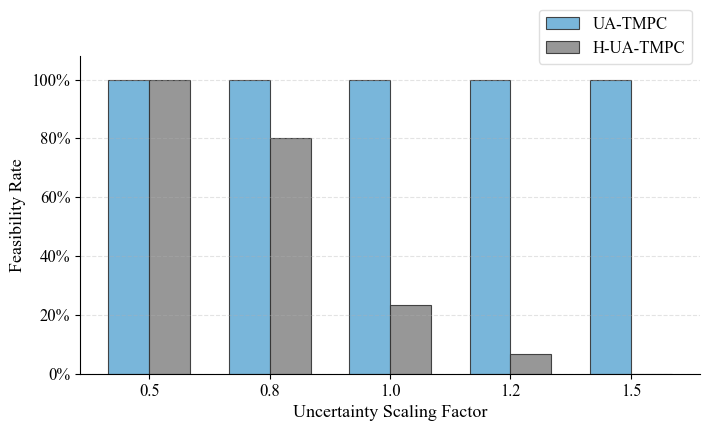

PosixPath('/Users/liqi/Desktop/UATMPC codes/UATMPC/figures/accuracy_sensitivity_www_07_solvability.pdf')

In [17]:
from matplotlib import pyplot as plt
from matplotlib.ticker import PercentFormatter
import numpy as np

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif"],
    "mathtext.fontset": "stix",
    "axes.labelsize": 13,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
})

method_styles = {
    "soft_ua_tube": {"label": "UA-TMPC", "color": "#6BAED6"},
    "hard_ua_tube": {"label": "H-UA-TMPC", "color": "#8C8C8C"},
}
method_order = ["soft_ua_tube", "hard_ua_tube"]

plot_sol = solvability_df.sort_values("www_value")
sol_pivot = plot_sol.pivot(index="www_value", columns="method", values="feasibility_rate")
x_values = sol_pivot.index.to_numpy()
x_pos = np.arange(len(x_values))
bar_width = 0.34

fig, ax = plt.subplots(figsize=(7.2, 4.4))

for i, method in enumerate(method_order):
    if method not in sol_pivot.columns:
        continue
    style = method_styles[method]
    offset = (i - (len(method_order) - 1) / 2) * bar_width
    ax.bar(
        x_pos + offset,
        sol_pivot[method],
        width=bar_width,
        color=style["color"],
        edgecolor="#333333",
        linewidth=0.8,
        alpha=0.9,
        label=style["label"],
    )

ax.set_xlabel("Uncertainty Scaling Factor")
ax.set_ylabel("Feasibility Rate")
ax.set_ylim(0, 1.08)
ax.set_xticks(x_pos)
ax.set_xticklabels([f"{value:.1f}" for value in x_values])
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1.0))
ax.grid(True, axis="y", linestyle="--", linewidth=0.8, alpha=0.35)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(
    loc="lower right",
    bbox_to_anchor=(1.0, 0.95),
    frameon=True,
    framealpha=0.95,
    edgecolor="#DDDDDD",
)

fig.tight_layout()
solvability_fig = figures_dir / f"accuracy_sensitivity_www_{candidate_month:02d}_solvability.pdf"
fig.savefig(solvability_fig, bbox_inches="tight")
plt.show()
solvability_fig

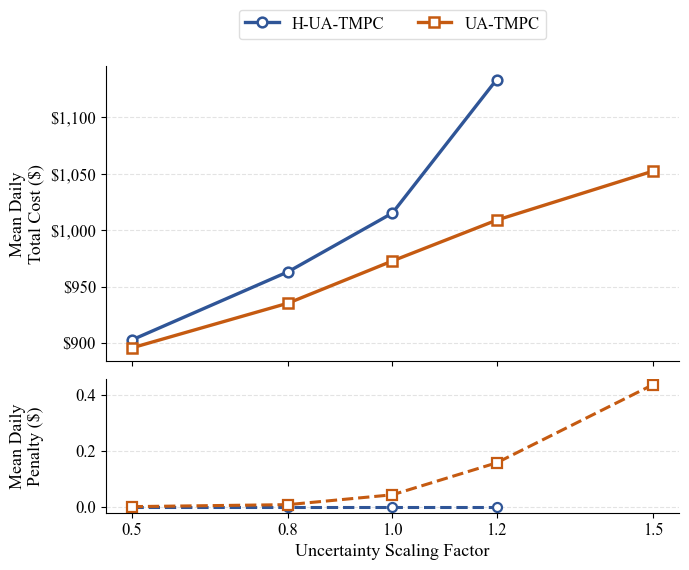

PosixPath('/Users/liqi/Desktop/UATMPC codes/UATMPC/figures/accuracy_sensitivity_www_07_economics.pdf')

In [15]:
from matplotlib.ticker import StrMethodFormatter

plot_econ = economics_df.sort_values("www_value")
fig, (ax_cost, ax_penalty) = plt.subplots(
    2,
    1,
    figsize=(7.4, 5.8),
    sharex=True,
    gridspec_kw={"height_ratios": [2.2, 1.0], "hspace": 0.08},
)

econ_styles = {
    "hard_ua_tube": {"label": "H-UA-TMPC", "color": "#2F5597", "marker": "o"},
    "soft_ua_tube": {"label": "UA-TMPC", "color": "#C55A11", "marker": "s"},
}

for method, style in econ_styles.items():
    group = plot_econ[plot_econ["method"].eq(method)]
    if group.empty:
        continue
    ax_cost.plot(
        group["www_value"],
        group["total_cost_mean"],
        color=style["color"],
        marker=style["marker"],
        markersize=7,
        markerfacecolor="white",
        markeredgewidth=1.8,
        linewidth=2.4,
        label=style["label"],
    )
    ax_penalty.plot(
        group["www_value"],
        group["total_penalty_mean"],
        color=style["color"],
        marker=style["marker"],
        markersize=6.5,
        markerfacecolor="white",
        markeredgewidth=1.6,
        linewidth=2.2,
        linestyle="--",
    )

for ax in (ax_cost, ax_penalty):
    ax.grid(True, axis="y", linestyle="--", linewidth=0.8, alpha=0.35)
    ax.spines[["top", "right"]].set_visible(False)

ax_cost.set_ylabel("Mean Daily\nTotal Cost ($)")
ax_cost.yaxis.set_major_formatter(StrMethodFormatter("${x:,.0f}"))
ax_cost.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, 1.22),
    ncol=2,
    frameon=True,
    framealpha=0.95,
    edgecolor="#DDDDDD",
)

ax_penalty.set_xlabel("Uncertainty Scaling Factor")
ax_penalty.set_ylabel("Mean Daily\nPenalty ($)")
ax_penalty.set_xticks(sorted(plot_econ["www_value"].unique()))
ax_penalty.yaxis.set_major_formatter(StrMethodFormatter("{x:,.1f}"))

fig.align_ylabels([ax_cost, ax_penalty])
fig.tight_layout()
economics_fig = figures_dir / f"accuracy_sensitivity_www_{candidate_month:02d}_economics.pdf"
fig.savefig(economics_fig, bbox_inches="tight")
plt.show()
economics_fig